In [1]:
!pip install numpy==1.22.4

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.22.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.0 kB)
Using cached numpy-1.22.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.0
    Uninstalling numpy-1.21.0:
      Successfully uninstalled numpy-1.21.0


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from methods import IBU, NPU

In [60]:
R = np.array([[0.9,0.1],[0.1,0.9]])

In [61]:
N = 100000 #total number of counts
t = np.array([0.5,0.5])*N #truth level distribution
m = [np.random.poisson(t[i]) for i in range(len(t))] #include stat fluctuations
print("m: ", m)

m = np.random.multinomial(m[0],R[:,0])+ np.random.multinomial(m[1],R[:,1]) #include detector resolutions
p = [0.1,0.9] #prior

print("m smeared: ", m)
print("t: ", t)

m:  [50141, 50060]
m smeared:  [50068 50133]
t:  [50000. 50000.]


In [5]:
npu,mle = NPU(m,R,N)

2024-05-18 11:59:03.643443: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-18 11:59:06.428274: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38218 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-05-18 11:59:06.436768: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38218 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2024-05-18 11:59:06.438468: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/devi

In [62]:
ibu = IBU(m,p,R,10)

In [99]:
def dist(x,y,x0,y0):
     return np.sqrt((x-x0)** 2 + (y-y0)** 2)

In [107]:
from matplotlib.patches import Ellipse

def plot_point_cov(points, nstd=2, ax=None, **kwargs):
    """
    Plots an `nstd` sigma ellipse based on the mean and covariance of a point
    "cloud" (points, an Nx2 array).

    Parameters
    ----------
        points : An Nx2 array of the data points.
        nstd : The radius of the ellipse in numbers of standard deviations.
            Defaults to 2 standard deviations.
        ax : The axis that the ellipse will be plotted on. Defaults to the 
            current axis.
        Additional keyword arguments are pass on to the ellipse patch.

    Returns
    -------
        A matplotlib ellipse artist
    """
    pos = points.mean(axis=0)
    cov = np.cov(points, rowvar=False)
    return plot_cov_ellipse(cov, pos, nstd, ax, **kwargs)

def plot_cov_ellipse(cov, pos, nstd=2, ax=None, **kwargs):
    """
    Plots an `nstd` sigma error ellipse based on the specified covariance
    matrix (`cov`). Additional keyword arguments are passed on to the 
    ellipse patch artist.

    Parameters
    ----------
        cov : The 2x2 covariance matrix to base the ellipse on
        pos : The location of the center of the ellipse. Expects a 2-element
            sequence of [x0, y0].
        nstd : The radius of the ellipse in numbers of standard deviations.
            Defaults to 2 standard deviations.
        ax : The axis that the ellipse will be plotted on. Defaults to the 
            current axis.
        Additional keyword arguments are pass on to the ellipse patch.

    Returns
    -------
        A matplotlib ellipse artist
    """
    def eigsorted(cov):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        return vals[order], vecs[:,order]

    if ax is None:
        ax = plt.gca()

    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height are "full" widths, not radius
    width, height = 2 * nstd * np.sqrt(vals)
    ellip = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)

    ax.add_artist(ellip)
    return ellip


In [100]:
nstrap = 1000
straps, r = [], []

for i in range(nstrap):
    m_i = [np.random.poisson(m[i]) for i in range(len(m))]
    # print(m_i)
    ibu_i = IBU(m_i,p,R,10)
    straps.append(ibu_i)
    r.append( dist( ibu_i[0], ibu_i[1], ibu[0], ibu[1] ) )
    # plt.scatter(ibu_i[0],ibu_i[1], color='grey')
straps = np.asarray(straps)
r = np.asarray(r)
# print(straps.shape)
# print(npu.shape)

In [108]:
# import scipy.stats as st
# rv = st.rv_discrete(values=(r, r/r.sum()))
# ci = rv.interval(0.68)
# print(np.where(r==ci))

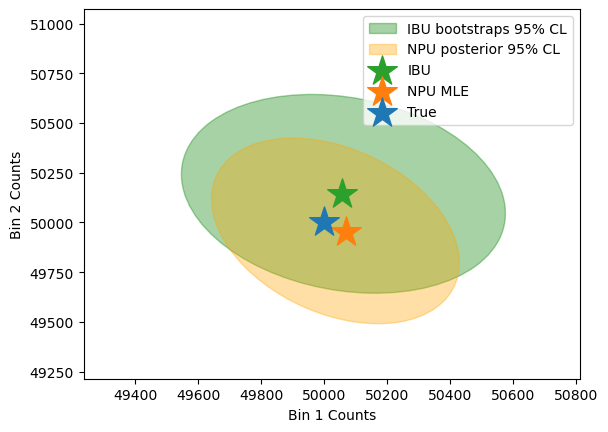

In [128]:
plot_point_cov(straps, nstd=2, alpha=0.35, color='green',label="IBU bootstraps 95% CL")
plot_point_cov(npu, nstd=2, alpha=0.35, color='orange',label="NPU posterior 95% CL")
plt.scatter(npu[:,0],npu[:,1], alpha=0.0001, color='orange')
plt.scatter(straps[:,0],straps[:,1], alpha=0.0001, color='green')
# plt.contour([straps[:,0],straps[:,1]]
plt.scatter(ibu[0],ibu[1], marker='*', label="IBU",s=500, color='tab:green')
plt.scatter(mle[0],mle[1], marker='*', label="NPU MLE",s=500, color='tab:orange')
plt.scatter(t[0],t[1], marker='*', label="True",s=500, color='tab:blue')
plt.legend()
plt.xlabel("Bin 1 Counts")
plt.ylabel("Bin 2 Counts")
plt.savefig('2bin.pdf', bbox_inches='tight')

Text(0.5, 0, 'Bin 1 Counts')

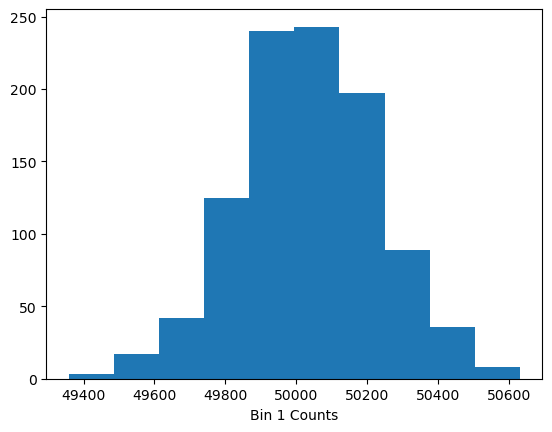

In [70]:
plt.hist(npu[:,0])
plt.xlabel("Bin 1 Counts")

In [71]:
R2 = np.array([[0.5,0.5],[0.5,0.5]])

In [72]:
t2 = np.array([0.5,0.5])*N #true
m2 = [np.random.poisson(t2[i]) for i in range(len(t2))] #stat fluctuations
m2 = np.random.multinomial(m2[0],R2[:,0])+np.random.multinomial(m2[1],R2[:,1]) #resolutions
p2 = [0.1,0.9] #prior

In [85]:
npu2,mle2 = NPU(m2,R2,N)

In [86]:
ibu2 = IBU(m2,p2,R2,10)

In [87]:
nstrap = 1000
straps2 = []

for i in range(nstrap):
    m_i = [np.random.poisson(m2[i]) for i in range(len(m2))]
    # print(m_i)
    ibu_i = IBU(m_i,p,R2,10)
    straps2.append(ibu_i)
    # plt.scatter(ibu_i[0],ibu_i[1], color='grey')
straps2 = np.asarray(straps2)
# print(straps)
# print(npu.shape)

[[50033. 49611.]
 [49937. 50115.]
 [49891. 50059.]
 ...
 [49875. 49985.]
 [50399. 50077.]
 [50091. 50171.]]


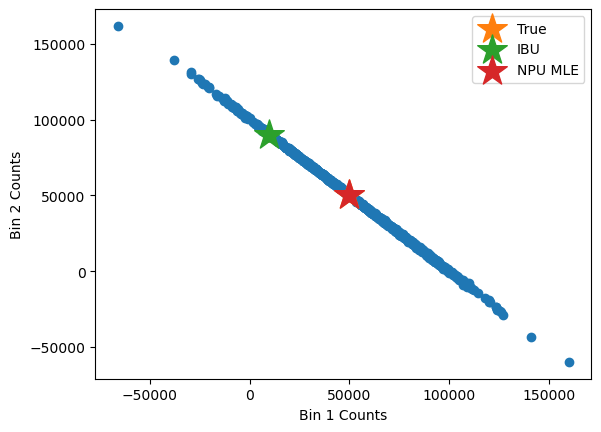

In [94]:
plot_point_cov(straps2, nstd=2, alpha=0.35, color='green',label="IBU bootstraps 95% CL")
plot_point_cov(npu2, nstd=2, alpha=0.35, color='orange',label="NPU posterior 95% CL")
plt.scatter(npu2[:,0],npu2[:,1], alpha=0.0001, color='orange')
plt.scatter(straps2[:,0],straps2[:,1], alpha=0.0001, color='green')
# plt.contour([straps[:,0],straps[:,1]]
plt.scatter(ibu[0],ibu[1], marker='*', label="IBU",s=500, color='tab:green')
plt.scatter(mle[0],mle[1], marker='*', label="NPU MLE",s=500, color='tab:orange')
plt.scatter(t[0],t[1], marker='*', label="True",s=500, color='tab:blue')
plt.legend()
plt.xlabel("Bin 1 Counts")
plt.ylabel("Bin 2 Counts")
plt.savefig('2bin_degenerateResp.pdf', bbox_inches='tight')

Text(0.5, 0, 'Bin 1 Counts')

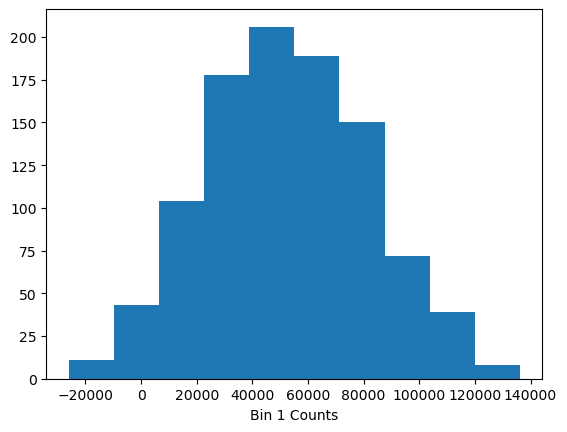

In [76]:
plt.hist(npu2[:,0])
plt.xlabel("Bin 1 Counts")